# Research Questions For Data Analysis
1. How does fraud volume and the fraud rate fluctuate across different months?
2. Does customer gender play a significant role in distribution of fraudulent transactions?
3. Which economic demographic (Income Group) exhibits the highest vulnerability to fraud?
4. What are the top 5 merchant business categories heavily exploited by fraudsters?
5. How do technical environments (Device Type and Operating System) impact transactional fraud rates?
6. Which banking entities bear the highest volume of transactional vulnerabilities?
7. Which payment mechanisms carry the highest systemic fraud risk?
8. Is there an observable variance in fraud across different card processing networks?
9. How effectively does the engine's internal risk score separate fraudulent records from legitimate actions?
10. What age groups carry the largest total volume of fraudulent transaction activities?

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_column', None)

# Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\arman\OneDrive\Desktop\Financial Fraud Detection System\Data\finance_fraud_dataset.csv")
df.head()

,transaction_id,customer_id,customer_age,customer_gender,income_group,bank_name,card_type,transaction_amount,transaction_type,transaction_time,transaction_location,state,device_type,operating_system,merchant_category,previous_transactions_count,account_balance,international_transaction,failed_login_attempts,suspicious_ip_flag,new_device_login,risk_score,is_fraud
0,TXN0000001,CUST402537,49,Male,Upper-Middle,Bandhan Bank,Visa,5085.46,Debit Card,10/25/2025,Nagpur,Gujarat,desktop,Android,Fuel,91,1155988.45,0,8,0,0,15,0
1,TXN0000002,CUST590435,37,Male,Low,HSBC India,RuPay,5918.67,Credit Card,7/7/2025,Agra,Uttar Pradesh,POS,Linux,Healthcare,61,637335.71,0,5,0,0,0,0
2,TXN0000003,CUST488921,63,Female,Low,PNB,RuPay,202.21,IMPS,7/27/2025,Delhi,Delhi,POS,iOS,Entertainment,1,103279.87,0,6,0,0,25,0
3,TXN0000004,CUST289957,62,Male,Low,ICICI,Visa,1317.15,Credit Card,3/19/2025,Chandigarh,Jammu & Kashmir,POS,Android,Insurance,145,1162845.82,0,5,0,1,15,0
4,TXN0000005,CUST568164,26,Male,Middle,Canara Bank,MasterCard,8092.44,ATM Withdrawal,8/24/2025,Prayagraj,Karnataka,mobile,Windows,Fuel,45,90952.53,1,10,0,1,50,1


# Data Analysis

## 1. How does fraud volume and the fraud rate fluctuate across different months?

In [5]:
# Extract month, year column
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['month_year'] = df['transaction_time'].dt.to_period('M').astype(str)

In [6]:
# Agreggating monthly metrics
monthly_data = df.groupby('month_year')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
monthly_data.columns = ['Month', 'Total_Transactions', 'Fraud_Cases', 'Fraud_Rate']
monthly_data = monthly_data.sort_values('Month')

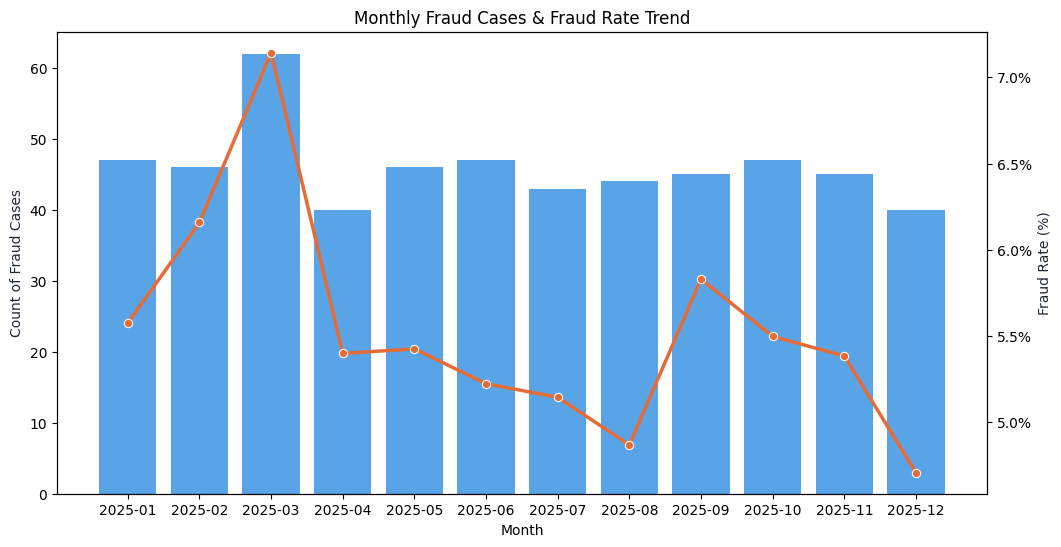

      Month  Total_Transactions  Fraud_Cases  Fraud_Rate
0   2025-01                 843           47    0.055753
1   2025-02                 747           46    0.061580
2   2025-03                 868           62    0.071429
3   2025-04                 741           40    0.053981
4   2025-05                 848           46    0.054245
5   2025-06                 900           47    0.052222
6   2025-07                 836           43    0.051435
7   2025-08                 904           44    0.048673
8   2025-09                 772           45    0.058290
9   2025-10                 855           47    0.054971
10  2025-11                 836           45    0.053828
11  2025-12                 850           40    0.047059


In [7]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=monthly_data, x='Month', y='Fraud_Cases', color='#118DFF', alpha=0.8, ax=ax1)
ax1.set_ylabel("Count of Fraud Cases", color='#1F2937')

ax2 = ax1.twinx()
sns.lineplot(data=monthly_data, x='Month', y='Fraud_Rate', color='#E66C37', linewidth=2.5, marker='o', ax=ax2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
ax2.set_ylabel("Fraud Rate (%)", color='#1F2937')

plt.title("Monthly Fraud Cases & Fraud Rate Trend")
plt.show()

print(monthly_data)

### `Insights:`

• Fraud peaks significantly in March 2025, reaching the highest fraud rate of 7.14% with 62 confirmed cases. Conversely, December 2025 records the lowest vulnerability, dropping to a fraud rate of 4.71% (40 cases).

## 2. Does customer gender play a significant role in distribution of fraudulent transactions?

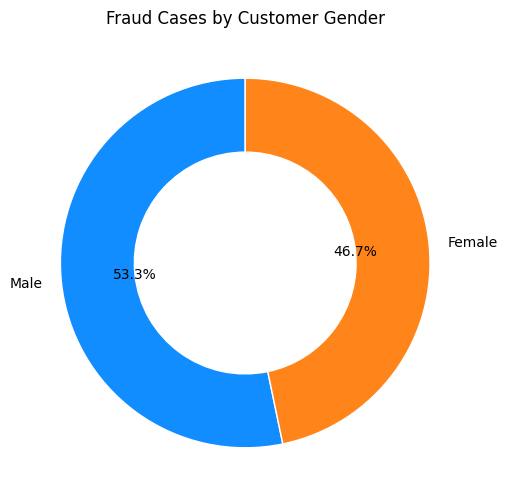

customer_gender
Male      294
Female    258
Name: count, dtype: int64


In [8]:
# Filtering for fraudulent cases only
fraud_df = df[df['is_fraud'] == 1]
gender_counts = fraud_df['customer_gender'].value_counts()

# Plotting Donut Chart
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, 
        colors=['#118DFF', '#FF851B'], wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title("Fraud Cases by Customer Gender")
plt.show()

print(gender_counts)

### `Insights:` 

• Male customers account for a slightly higher volume of fraud with 53.3% (294 cases) compared to female customers, who represent 46.7% (258 cases) of the total fraud dataset.

## 3. Which economic demographic (Income Group) exhibits the highest vulnerability to fraud?

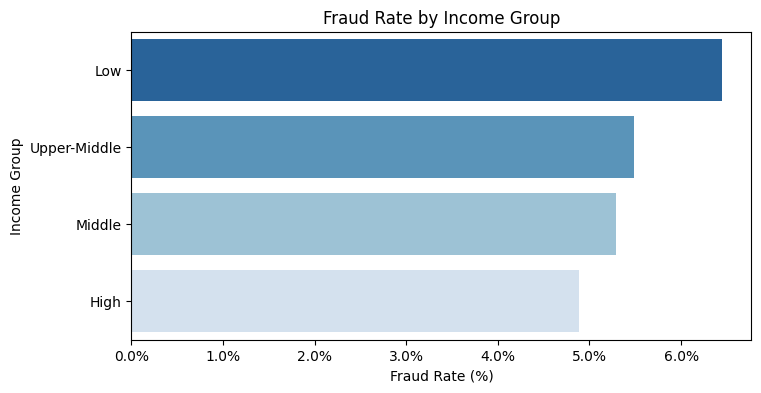

In [9]:
income_fraud = df.groupby('income_group')['is_fraud'].mean().reset_index()
income_fraud = income_fraud.sort_values('is_fraud', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=income_fraud, x='is_fraud', y='income_group', palette='Blues_r')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Income Group")
plt.title("Fraud Rate by Income Group")
plt.show()

### `Insights:` 

• The Low-income group is the most targeted demographic, displaying the highest baseline fraud rate of 6.45%. In contrast, the High-income group shows the lowest overall fraud velocity at 4.89%.

## 4. What are the top 5 merchant business categories heavily exploited by fraudsters?

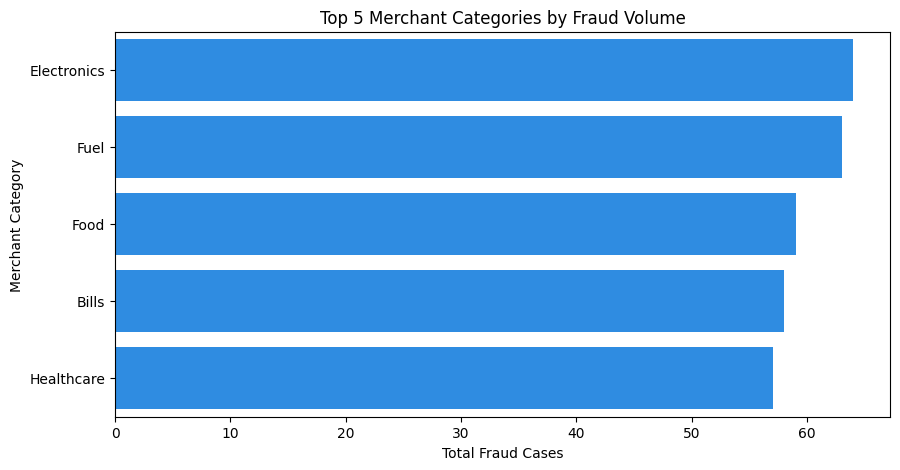

In [10]:
merchant_fraud = df.groupby('merchant_category')['is_fraud'].sum().reset_index()
top_merchants = merchant_fraud.sort_values('is_fraud', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_merchants, x='is_fraud', y='merchant_category', color='#118DFF')
plt.xlabel("Total Fraud Cases")
plt.ylabel("Merchant Category")
plt.title("Top 5 Merchant Categories by Fraud Volume")
plt.show()

### `Insights:` 

• Electronics (64 cases) and Fuel stations (63 cases) emerge as the leading merchant categories where fraudulent transactions are most successfully finalized.

## 5. How do technical environments (Device Type and Operating System) impact transactional fraud rates?

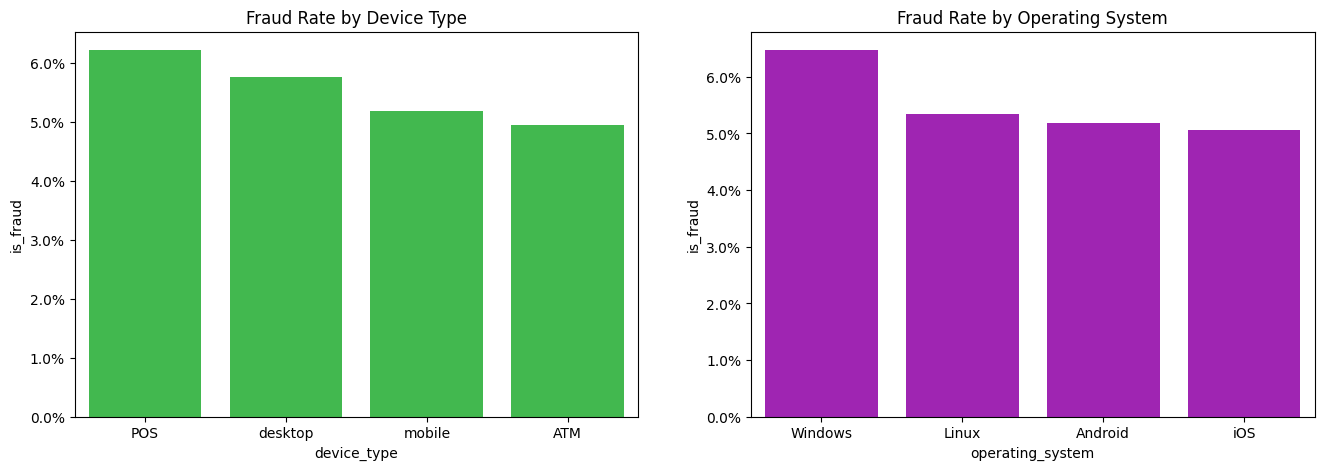

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Device type
device_fraud = df.groupby('device_type')['is_fraud'].mean().reset_index().sort_values('is_fraud', ascending=False)
sns.barplot(data=device_fraud, x='device_type', y='is_fraud', color='#2ECC40', ax=axes[0])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
axes[0].set_title("Fraud Rate by Device Type")

# OS
os_fraud = df.groupby('operating_system')['is_fraud'].mean().reset_index().sort_values('is_fraud', ascending=False)
sns.barplot(data=os_fraud, x='operating_system', y='is_fraud', color='#B10DC9', ax=axes[1])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
axes[1].set_title("Fraud Rate by Operating System")

plt.show()

### `Insights:` 

• Transactions processed via POS (Point of Sale) terminals experience the highest device-level fraud rate at 6.22%. System-wise, Windows operating system users are linked to the highest fraud density at 6.47%.

## 6. Which banking entities bear the highest volume of transactional vulnerabilities?

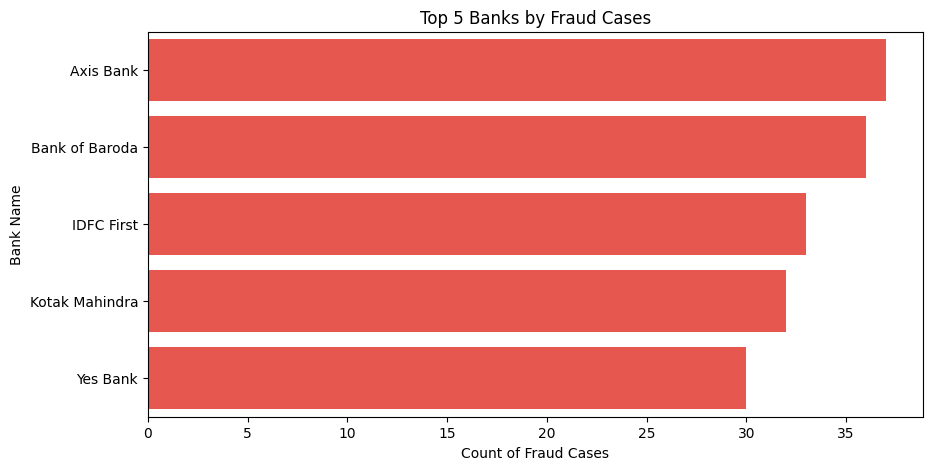

In [12]:
bank_fraud = df.groupby('bank_name')['is_fraud'].sum().reset_index()
top_banks = bank_fraud.sort_values('is_fraud', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_banks, x='is_fraud', y='bank_name', color='#FF4136')
plt.xlabel("Count of Fraud Cases")
plt.ylabel("Bank Name")
plt.title("Top 5 Banks by Fraud Cases")
plt.show()

### `Insights:` 

• Axis Bank registers the highest exposure with 37 fraud cases, closely followed by Bank of Baroda at 36 fraud cases, highlighting potential security loopholes or target focus on these banking pipelines.

## 7. Which payment mechanisms carry the highest systemic fraud risk?

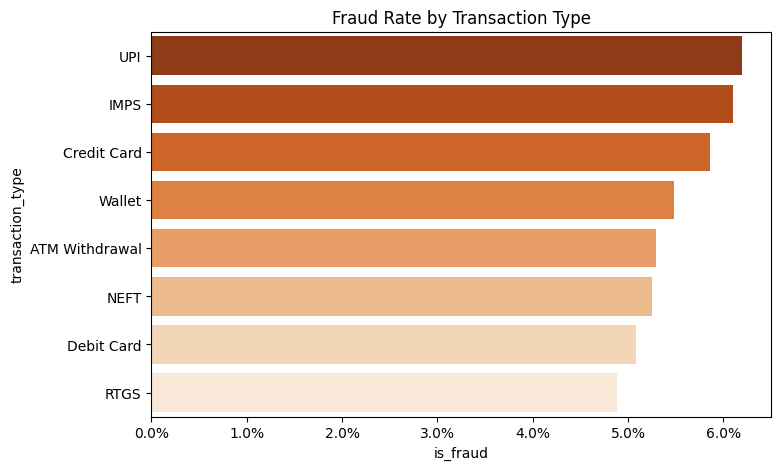

In [13]:
tx_type_fraud = df.groupby('transaction_type')['is_fraud'].mean().reset_index().sort_values('is_fraud', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=tx_type_fraud, x='is_fraud', y='transaction_type', palette='Oranges_r')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
plt.title("Fraud Rate by Transaction Type")
plt.show()

### `Insights:` 

• Instant payment rails have the highest attack rates, with UPI (6.19%) and IMPS (6.10%) proving to be the riskiest transaction channels in the financial ecosystem.

## 8. Is there an observable variance in fraud across different card processing networks?

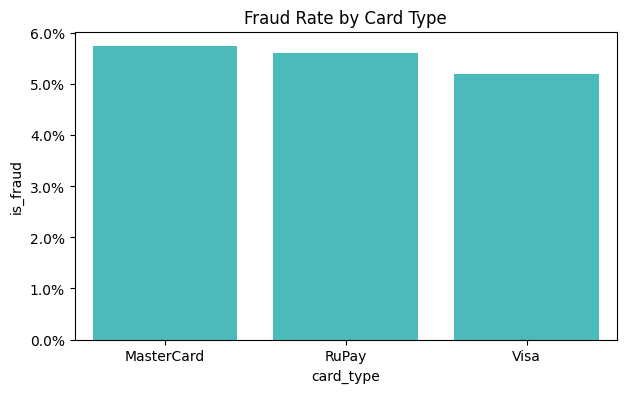

In [14]:
card_fraud = df.groupby('card_type')['is_fraud'].mean().reset_index().sort_values('is_fraud', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=card_fraud, x='card_type', y='is_fraud', color='#39CCCC')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.title("Fraud Rate by Card Type")
plt.show()

### `Insights:` 

• MasterCard transactions demonstrate a slightly elevated fraud rate at 5.74%, while RuPay sits at 5.61% and Visa indicates the lowest exposure rate at 5.21%.

## 9. How effectively does the engine's internal risk score separate fraudulent records from legitimate actions?

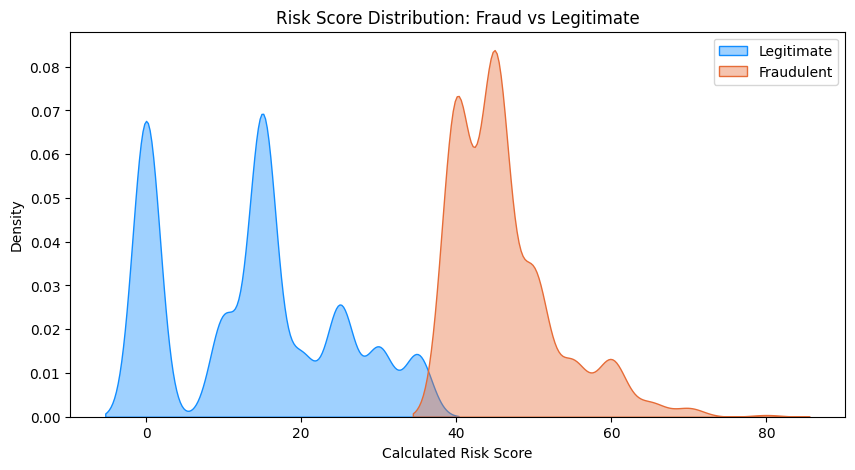

In [15]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['is_fraud']==0], x='risk_score', label='Legitimate', fill=True, color='#118DFF', alpha=0.4)
sns.kdeplot(data=df[df['is_fraud']==1], x='risk_score', label='Fraudulent', fill=True, color='#E66C37', alpha=0.4)
plt.xlabel("Calculated Risk Score")
plt.ylabel("Density")
plt.title("Risk Score Distribution: Fraud vs Legitimate")
plt.legend()
plt.show()

### `Insights:` 

• The kernel density distribution displays a pronounced separation. The curve for fraudulent transactions is noticeably shifted to the right towards higher risk scores, validating that the backend dynamic risk engine is operating effectively.

## 10. What age groups carry the largest total volume of fraudulent transaction activities?

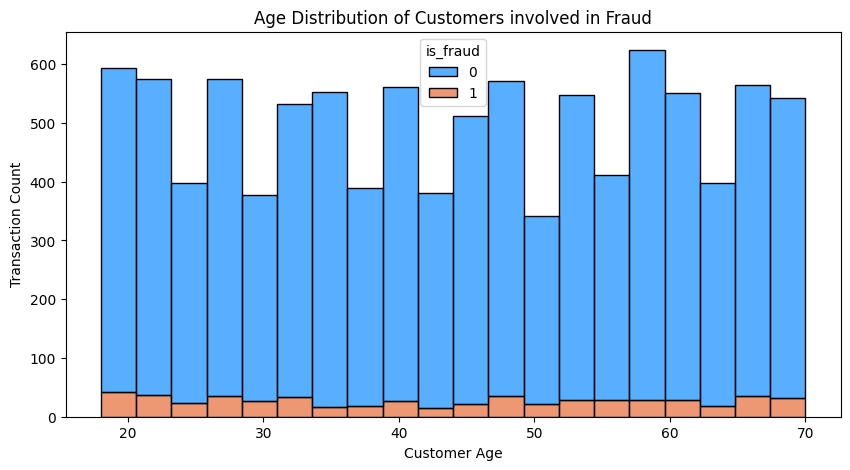

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='customer_age', hue='is_fraud', multiple='stack', bins=20, palette={0: '#118DFF', 1: '#E66C37'}, alpha=0.7)
plt.xlabel("Customer Age")
plt.ylabel("Transaction Count")
plt.gca().get_legend()
plt.title("Age Distribution of Customers involved in Fraud")
plt.show()

### `Insights:` 

• While incidents are scattered across all chronological ranges, the highest cluster volume of fraud targets active working adults falling within the 30 to 60 years old age bracket.